# Resultados - Simulação com evoluções de preferências de usuários 


A primeira parte do relatório contém os dados sem esquecimento de preferências.

In [12]:
from dynamicTasteDistortion.scripts.vis import plot_metric_comparison, plot_metrics_smoothed

In [8]:
# Versões sem evolução de preferências (alpha = 0)
bpr_debiased = "experiments/bpr_with_oracle_experiment.yaml"
random_rec = "experiments/random_rec_with_oracle_experiment.yaml"
most_popular = "experiments/most_popular_with_oracle_experiment.yaml"

# Versões com evolução de preferências (Porém, sem esquecimento)


bpr_debiased_alpha_0_1 = "experiments/evolving_preferences/bpr_unbiased_uncalibrated_alpha_0_1.yaml"
random_rec_alpha_0_1 = "experiments/evolving_preferences/random_rec_with_oracle_experiment_alpha_0_1.yaml"
most_popular_alpha_0_1 = "experiments/evolving_preferences/most_popular_with_oracle_experiment_alpha_0_1.yaml"

## Comparing static preferences with dynamic preferences

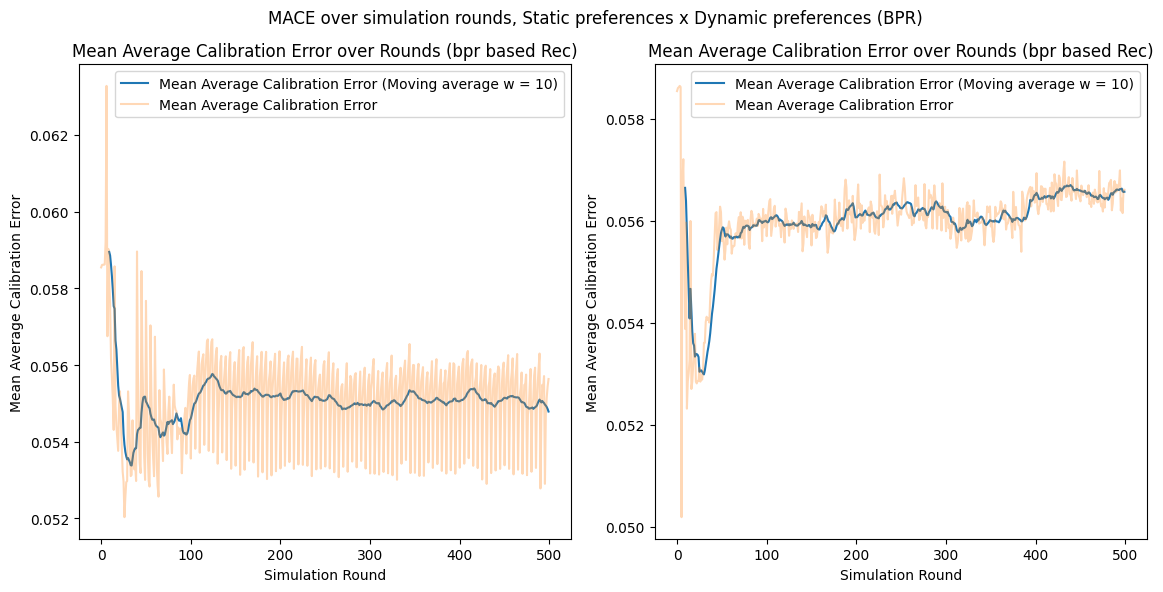

In [9]:
plot_metric_comparison(bpr_debiased, bpr_debiased_alpha_0_1, metric_name="mace", title="MACE over simulation rounds, Static preferences x Dynamic preferences (BPR)", graph="line", plot_retrain_points=False,  window_size=10)

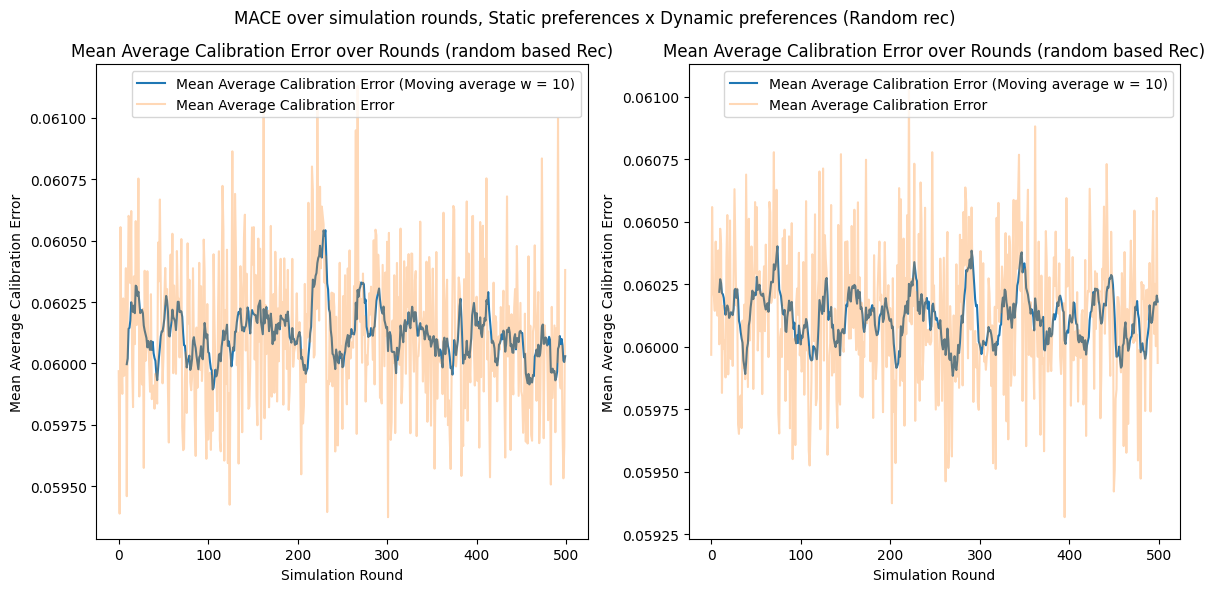

In [10]:
plot_metric_comparison(random_rec, random_rec_alpha_0_1, metric_name="mace", title="MACE over simulation rounds, Static preferences x Dynamic preferences (Random rec)", graph="line", plot_retrain_points=False,  window_size=10)

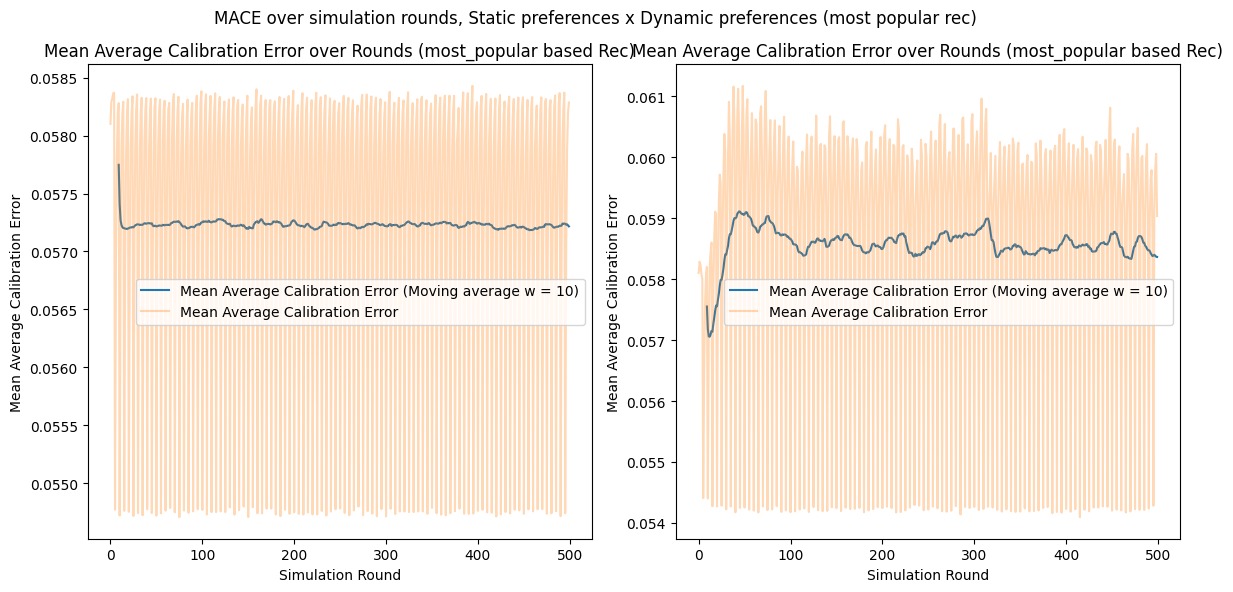

In [11]:
plot_metric_comparison(most_popular, most_popular_alpha_0_1, metric_name="mace", title="MACE over simulation rounds, Static preferences x Dynamic preferences (most popular rec)", graph="line", plot_retrain_points=False,  window_size=10)

## With calibration

In [30]:
bpr_constant_calibrated_alpha_0_1 = "experiments/evolving_preferences/bpr_unbiased_calibrated_alpha_0_1.yaml"
bpr_linear_time_calibrated_alpha_0_1 = "experiments/evolving_preferences/bpr_unbiased_linear_time_calibrated_alpha_0_1.yaml"


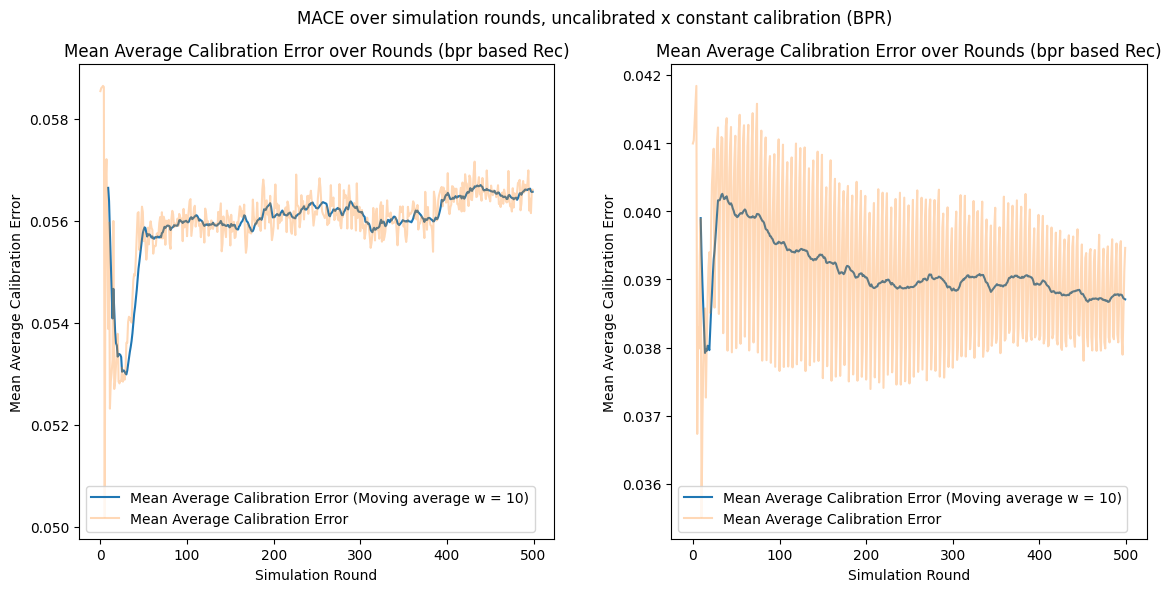

In [31]:
plot_metric_comparison(bpr_debiased_alpha_0_1, bpr_constant_calibrated_alpha_0_1, metric_name="mace", title="MACE over simulation rounds, uncalibrated x constant calibration (BPR)", graph="line", plot_retrain_points=False,  window_size=10)

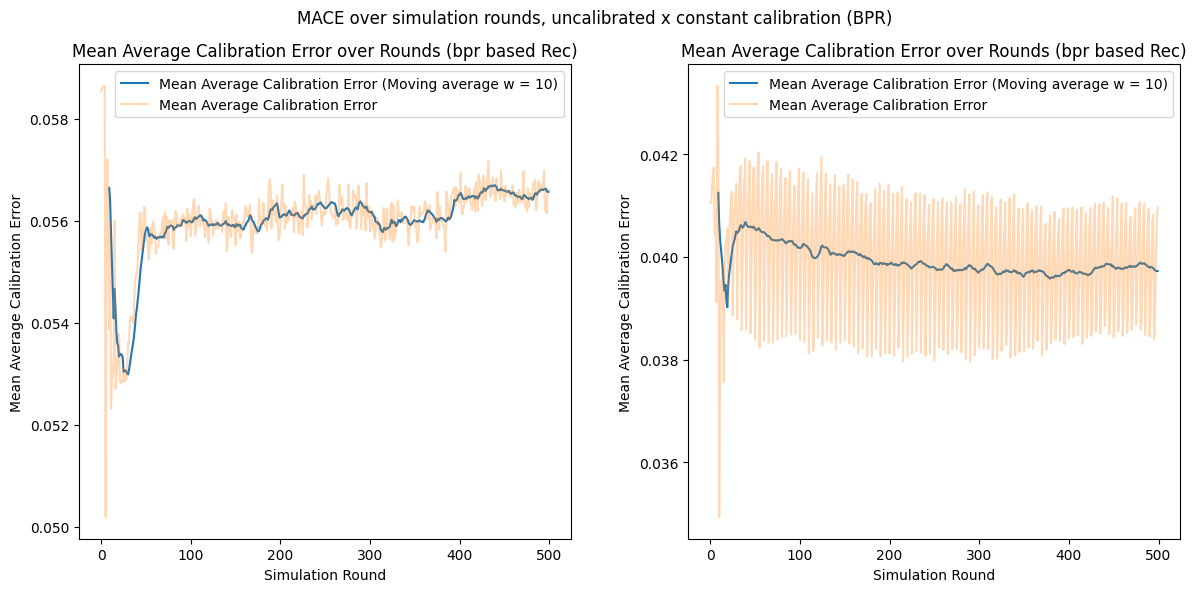

In [32]:
plot_metric_comparison(bpr_debiased_alpha_0_1, bpr_linear_time_calibrated_alpha_0_1, metric_name="mace", title="MACE over simulation rounds, uncalibrated x constant calibration (BPR)", graph="line", plot_retrain_points=False,  window_size=10)

## Different Alphas


In [13]:
from dynamicTasteDistortion.ioUtils import read_experiment, read_metrics

In [ ]:
plot_metrics_smoothed(ax=None, metric=mace_outliers_removed, model_name="BPR", metric_name="MACE", step=bpr_biased_exp["num_rounds_per_eval"], window_size=1000)

In [22]:
model_to_base_file_name = {
    "BPR": "bpr_unbiased_uncalibrated",
    "random_rec": "random_rec_with_oracle_experiment",
    "most_popular": "most_popular_with_oracle_experiment",
}

Metrics for model: BPR
Metrics for model: random_rec
Metrics for model: most_popular


/home/caio/dev/dynamicTasteDistortion/dynamicTasteDistortion/scripts/vis.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 5))


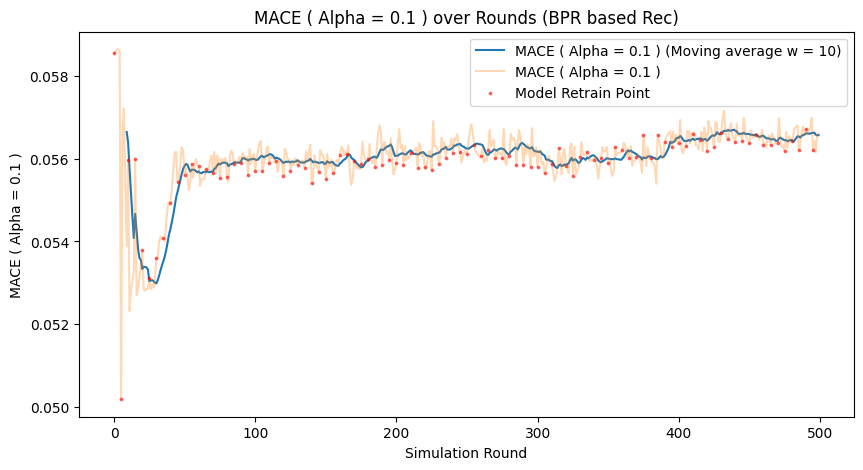

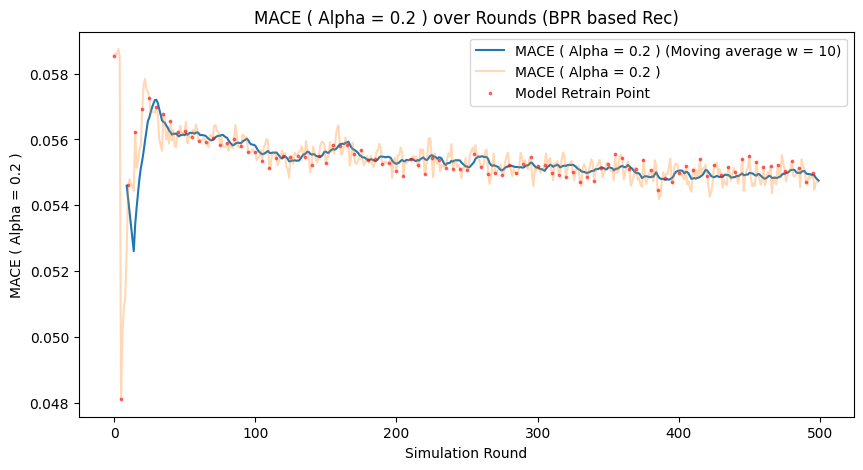

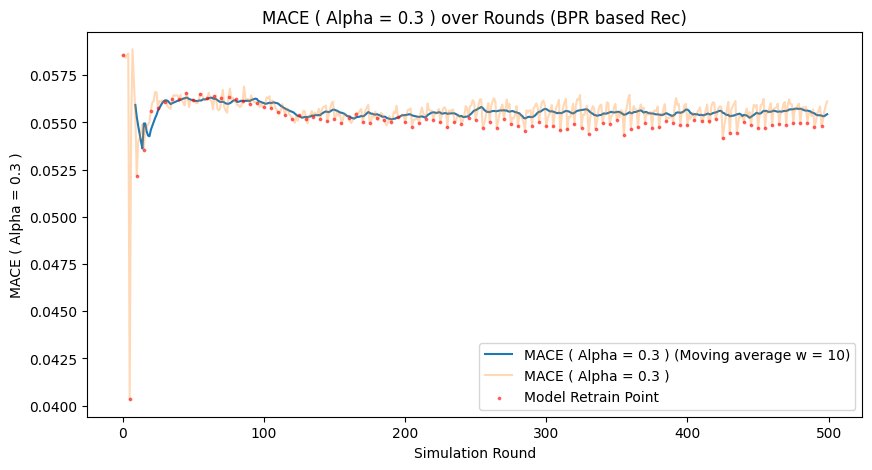

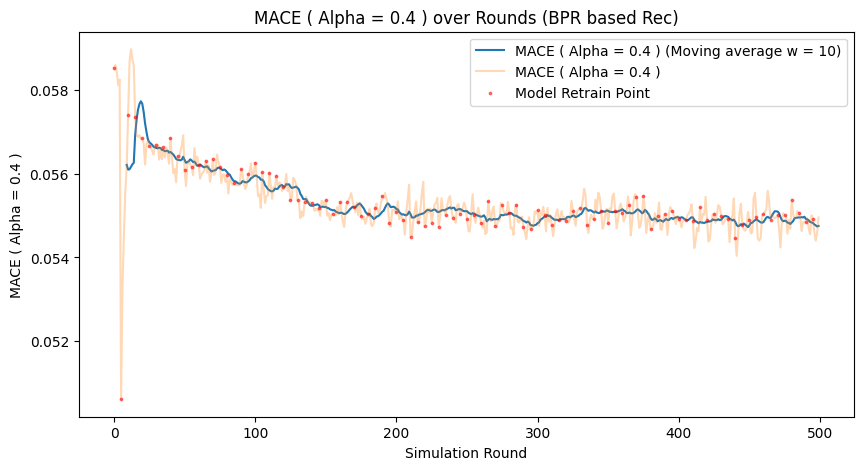

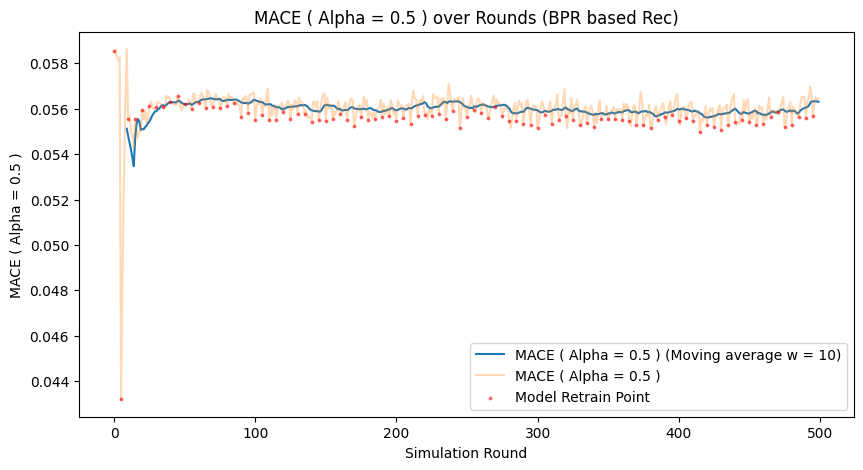

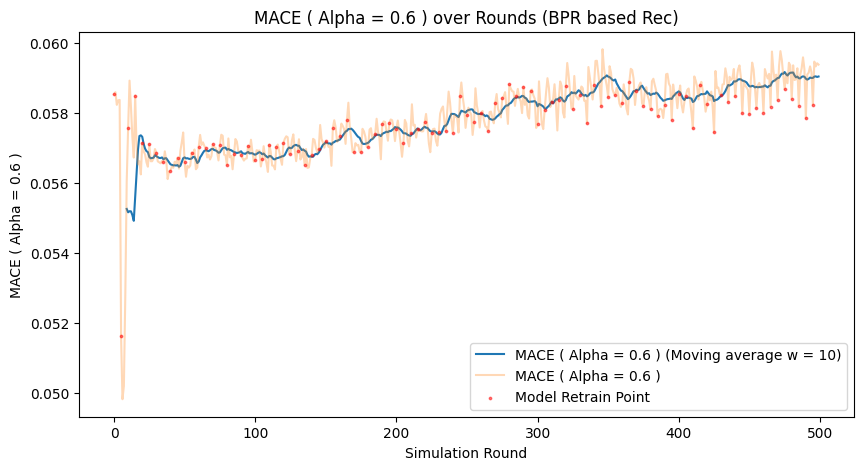

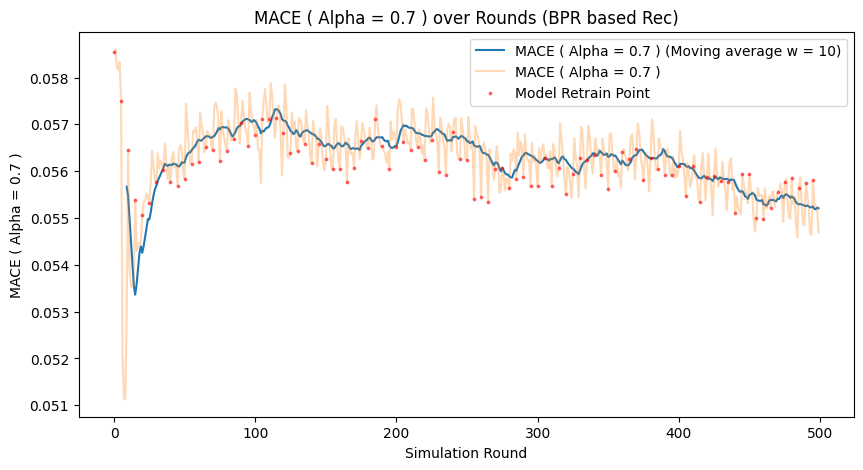

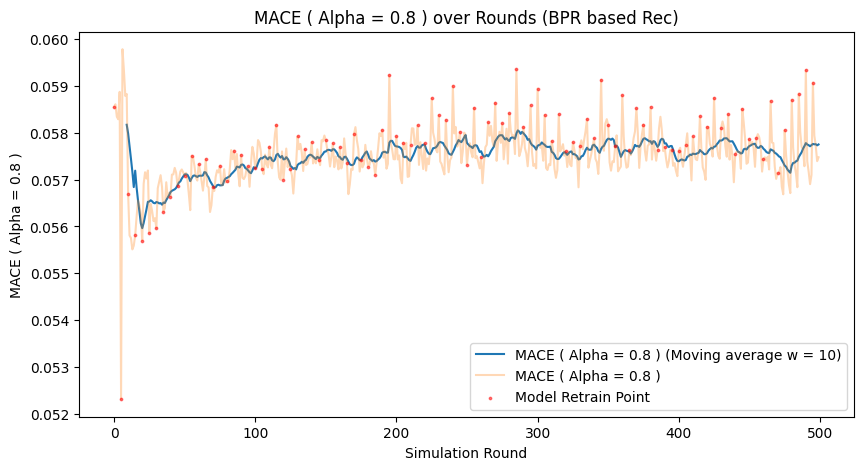

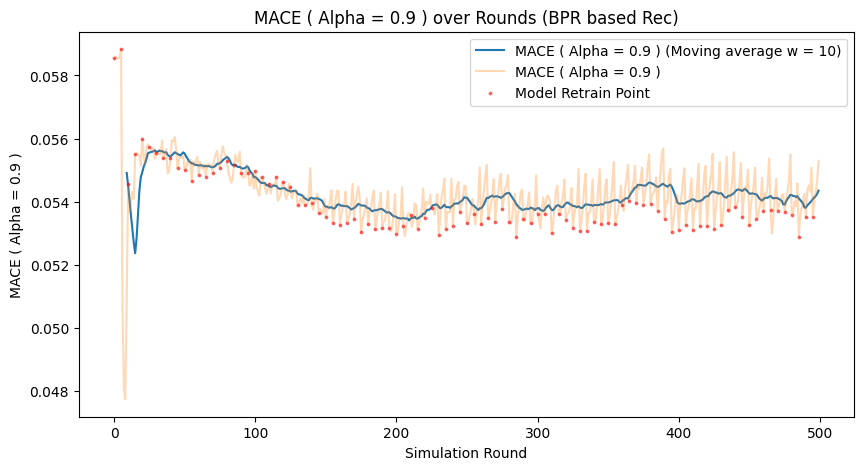

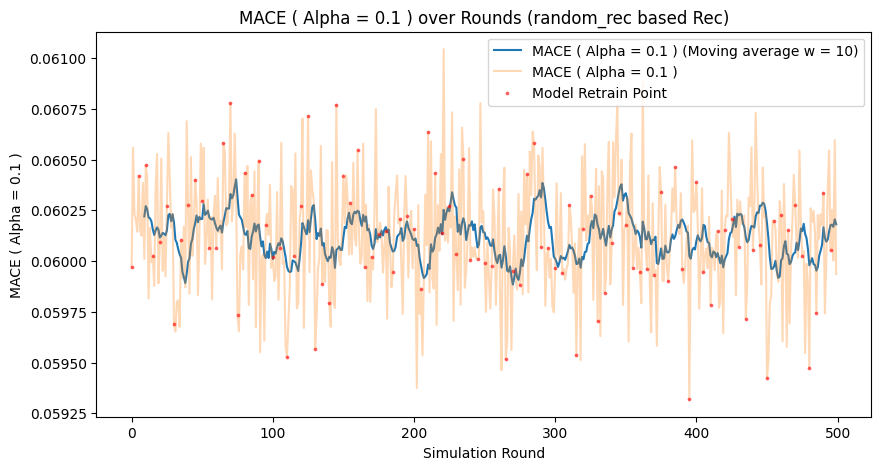

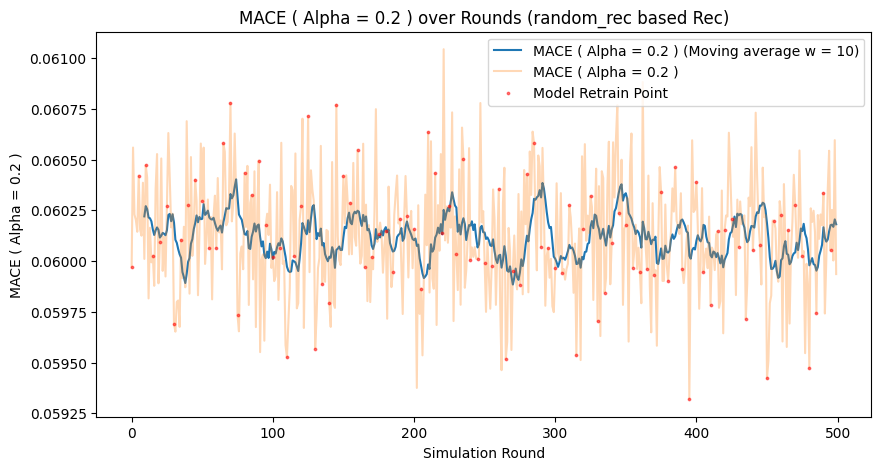

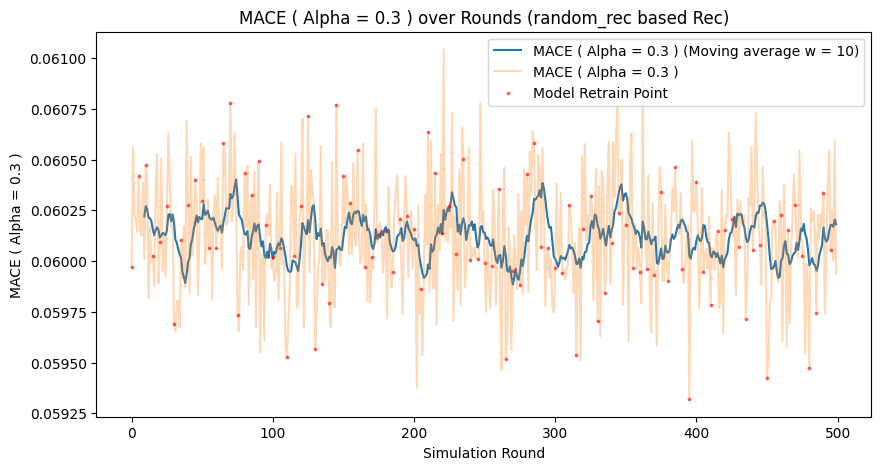

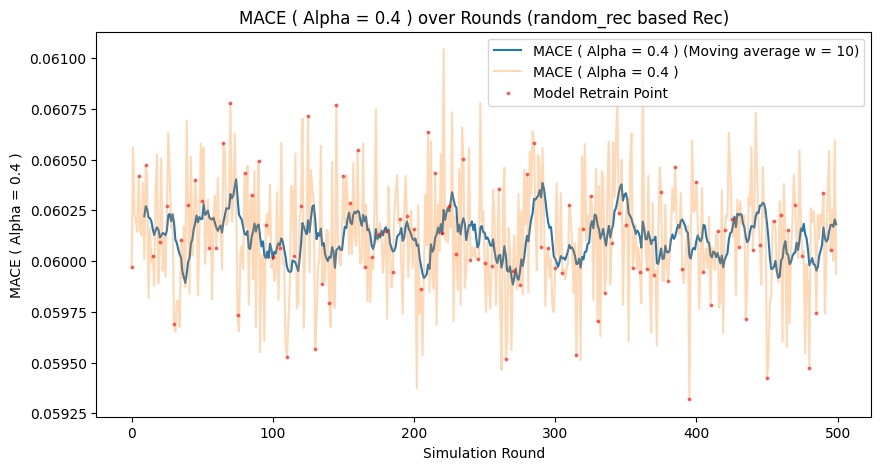

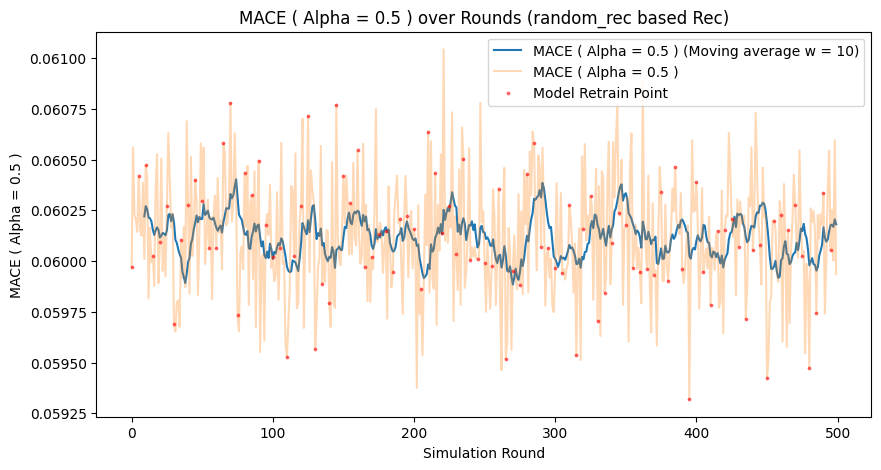

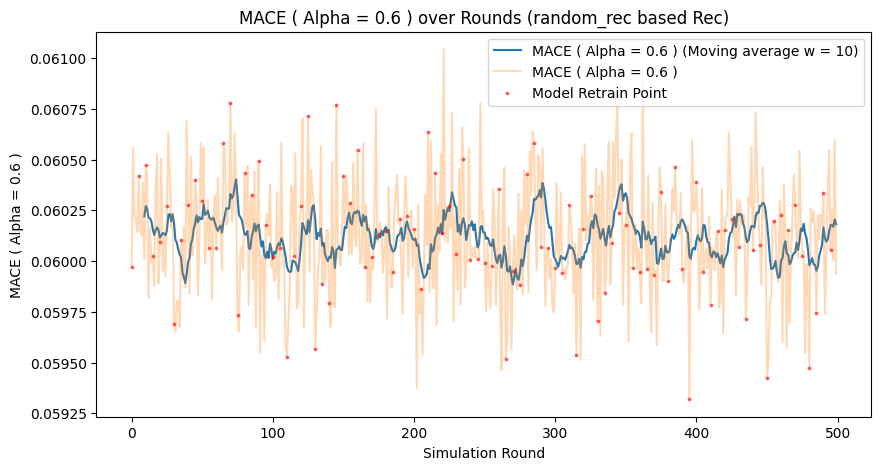

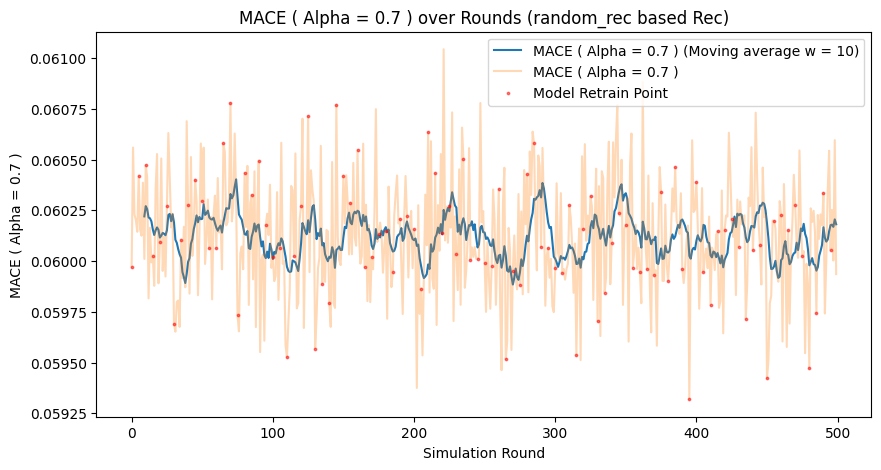

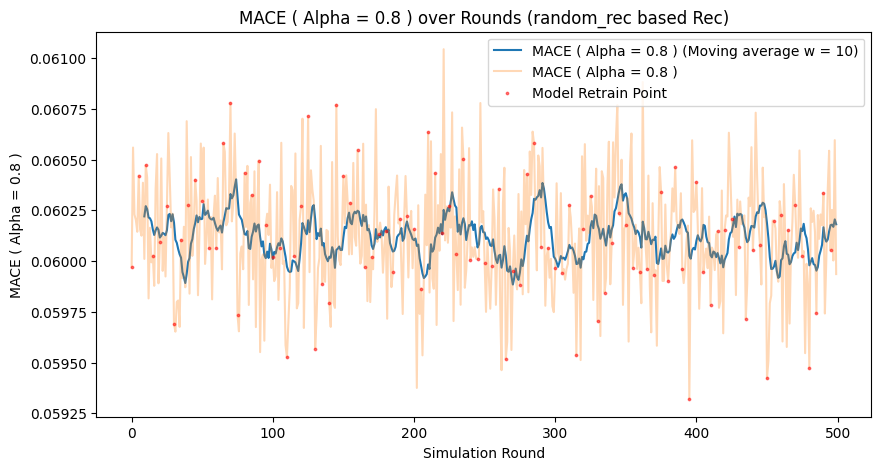

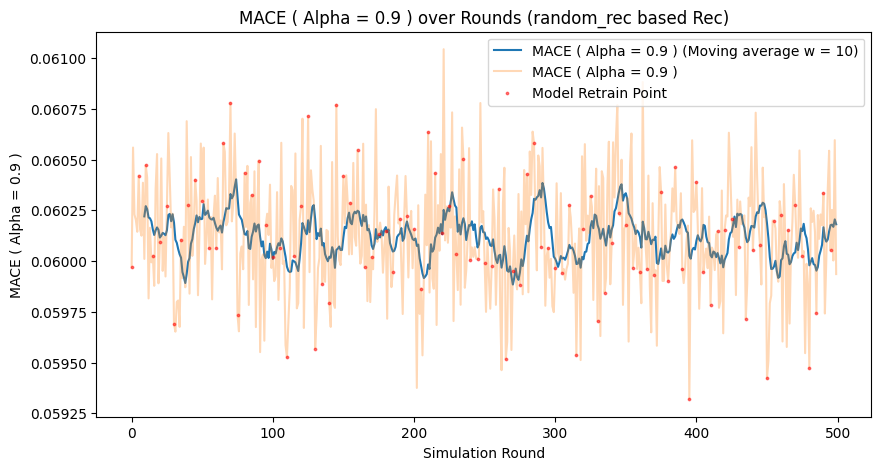

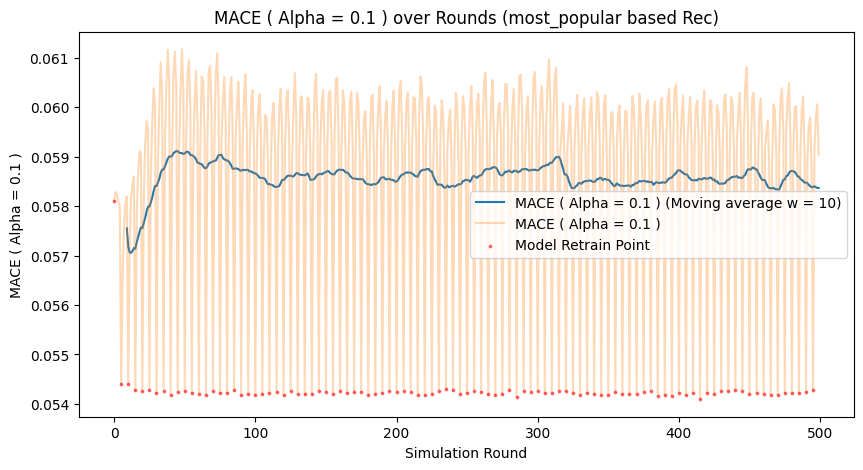

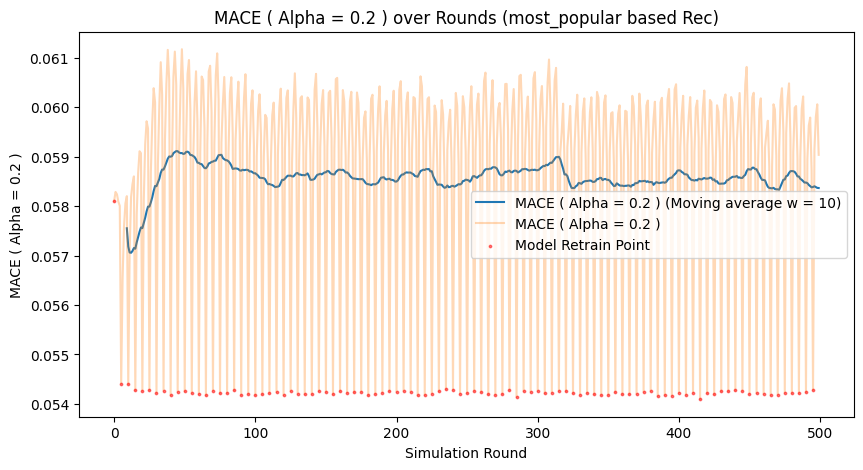

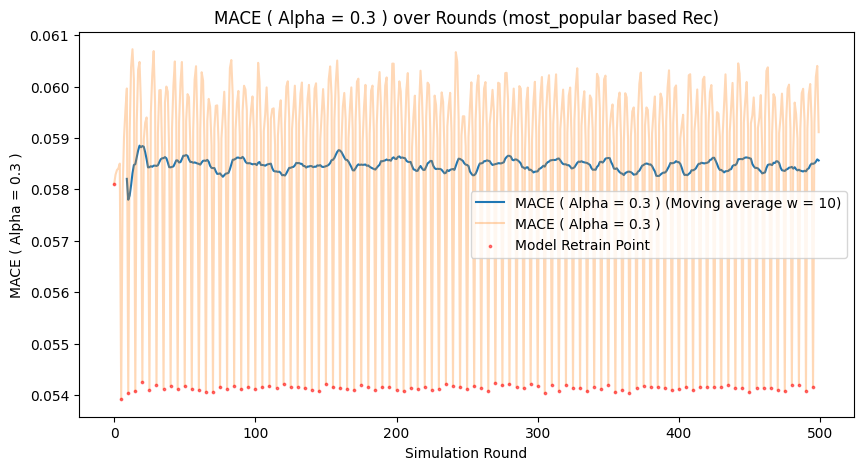

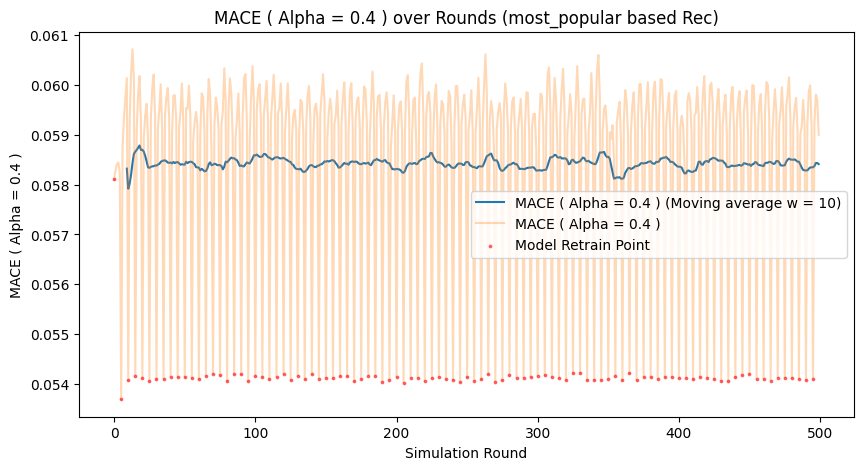

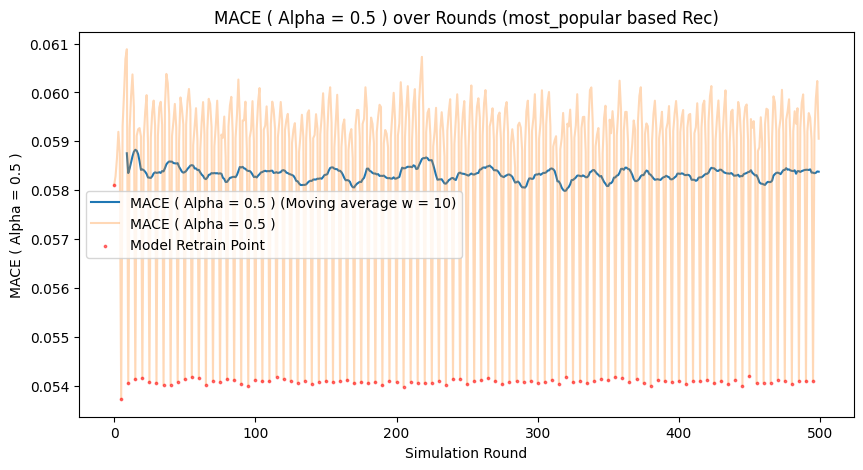

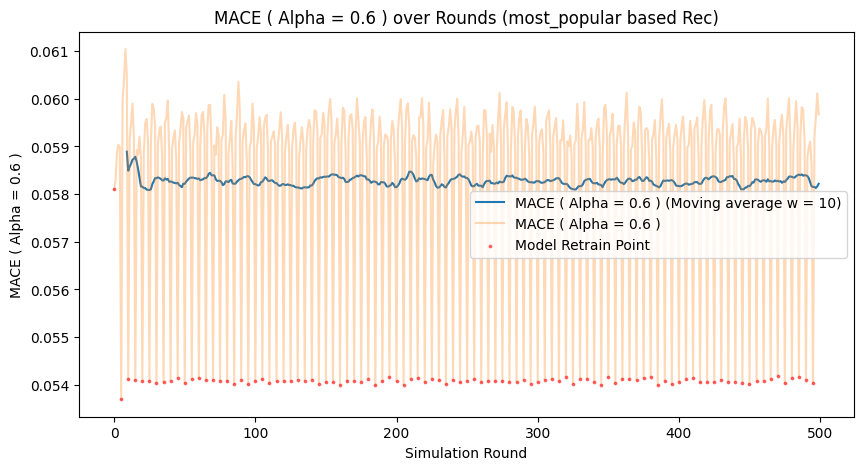

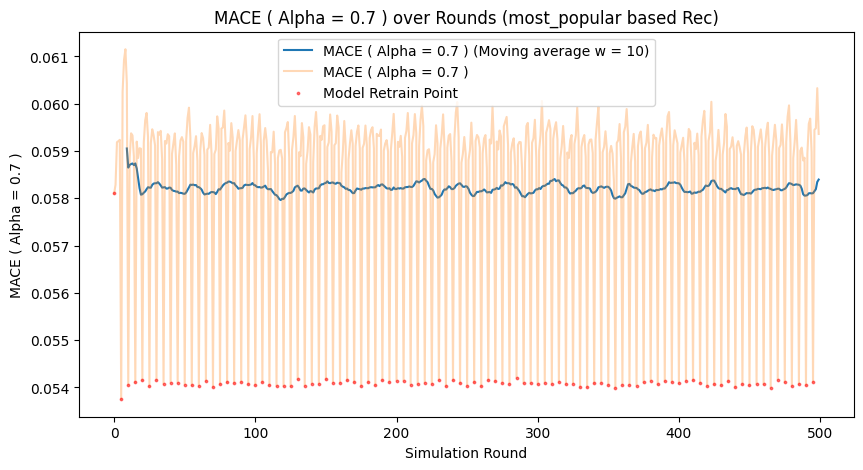

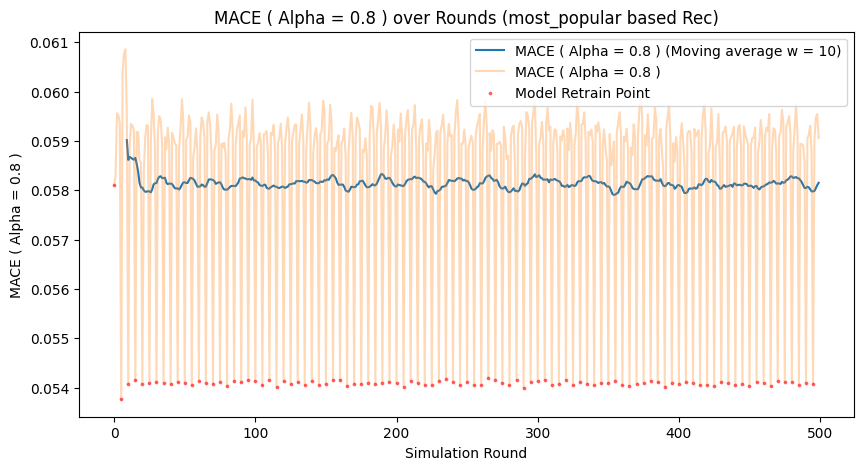

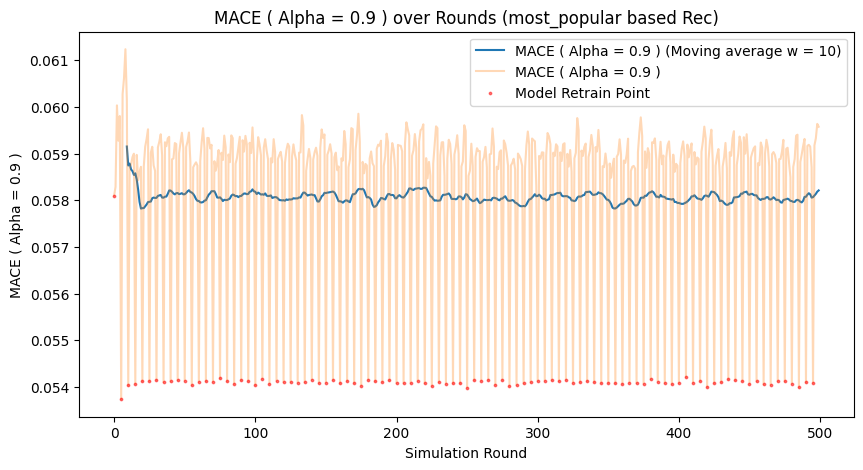

In [29]:
for model in ["BPR", "random_rec", "most_popular"]:
    print("Metrics for model:", model)
    base_path = f"experiments/evolving_preferences/{model_to_base_file_name[model]}"
    for alpha in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
        exp = read_experiment(f"{base_path}_alpha_0_{int(10*alpha)}.yaml")
        metrics = read_metrics(exp)
        mace = metrics[0]
        plot_metrics_smoothed(
            ax=None,
            metric=mace,
            model_name=model,
            metric_name=f"MACE ( Alpha = {alpha} )",
            step=exp["num_rounds_per_eval"],
            window_size=10
        )

In [ ]:
bpr_debiased_alpha_0_1 = "experiments/evolving_preferences/bpr_unbiased_uncalibrated_alpha_0_1.yaml"